# Práctica Final NLP — Modelado

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

## Carga del corpus preprocesado

In [ ]:
import os, re, string, unicodedata, urllib.request
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem.snowball import EnglishStemmer

sw = set(stopwords.words('english'))
stemmer = EnglishStemmer()

def preprocess_text(text, stem=False):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\b\d+\b', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in sw and len(w) >= 2]
    if stem:
        tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

files = [
    "reviews_Clothing_Shoes_and_Jewelry_5.json.gz",
    "reviews_Office_Products_5.json.gz",
    "reviews_Video_Games_5.json.gz"
]
base_url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/"

for f in files:
    if not os.path.exists(f):
        print(f"Descargando {f}...")
        urllib.request.urlretrieve(base_url + f, f)

df_clothing   = pd.read_json("reviews_Clothing_Shoes_and_Jewelry_5.json.gz", lines=True, compression='gzip')
df_office     = pd.read_json("reviews_Office_Products_5.json.gz", lines=True, compression='gzip')
df_videogames = pd.read_json("reviews_Video_Games_5.json.gz", lines=True, compression='gzip')

N = 10000
for df_ in [df_clothing, df_office, df_videogames]:
    df_['sentiment'] = df_['overall'].apply(lambda x: 0 if x < 3 else 1)

df = pd.concat([
    df_clothing[['reviewText','overall','sentiment']].dropna().sample(N, random_state=42),
    df_office[['reviewText','overall','sentiment']].dropna().sample(N, random_state=42),
    df_videogames[['reviewText','overall','sentiment']].dropna().sample(N, random_state=42)
]).reset_index(drop=True)

print("Aplicando preprocesado...")
df['reviewText_clean'] = df['reviewText'].apply(preprocess_text)
print("Listo:", df.shape)
print(df['sentiment'].value_counts())

Aplicando preprocesado...
Listo: (30000, 4)
sentiment
1    27302
0     2698
Name: count, dtype: int64


## Vectorización TF-IDF (Bag of Words)

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['reviewText_clean'])
y = df['sentiment']

print("Dimensiones de la matriz TF-IDF:", X.shape)

Dimensiones de la matriz TF-IDF: (30000, 10000)


## División train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (24000, 10000)
Test: (6000, 10000)


## Gestión del desbalanceo de clases

In [ ]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print("Pesos de clase:", class_weight_dict)

Pesos de clase: {0: np.float64(5.560704355885079), 1: np.float64(0.5494002380734365)}


## Modelo 1: Regresión Logística

In [ ]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negativa', 'Positiva']))

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

    Negativa       0.39      0.69      0.50       540
    Positiva       0.97      0.90      0.93      5460

    accuracy                           0.88      6000
   macro avg       0.68      0.79      0.72      6000
weighted avg       0.92      0.88      0.89      6000



## Modelo 2: Naive Bayes

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== NAIVE BAYES ===")
print(classification_report(y_test, y_pred_nb, target_names=['Negativa', 'Positiva']))

=== NAIVE BAYES ===
              precision    recall  f1-score   support

    Negativa       0.73      0.03      0.06       540
    Positiva       0.91      1.00      0.95      5460

    accuracy                           0.91      6000
   macro avg       0.82      0.51      0.51      6000
weighted avg       0.90      0.91      0.87      6000



## Comparativa de resultados

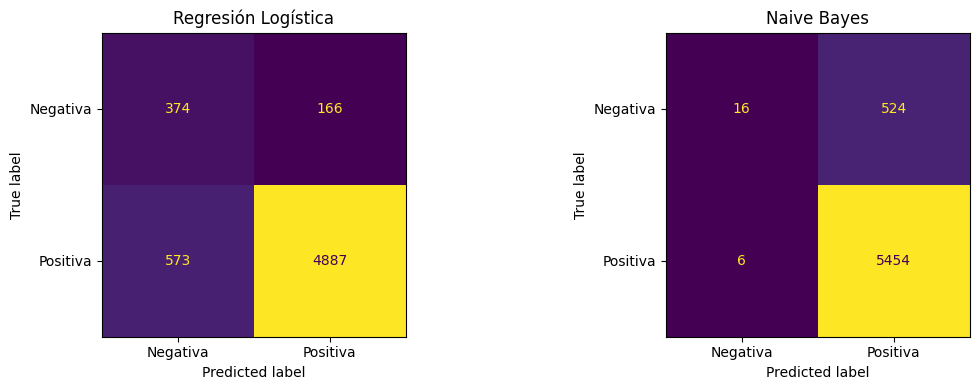

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Negativa', 'Positiva']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Regresión Logística')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_nb),
    display_labels=['Negativa', 'Positiva']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()

## Elección del modelo

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Naive Bayes'],
    'Precision': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted')
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ]
})

print(resultados.to_string(index=False))

             Modelo  Precision   Recall  F1-score
Regresión Logística   0.915649 0.876833  0.891305
        Naive Bayes   0.895689 0.911667  0.872958


## Conclusiones

| Modelo | Precision | Recall | F1-score |
|---|---|---|---|
| Regresión Logística | 0.916 | 0.877 | 0.891 |
| Naive Bayes | 0.896 | 0.912 | 0.873 |

Se elige la **Regresión Logística** como modelo final por las siguientes razones:

- Obtiene el **F1-score más alto (0.891)**, que es la métrica más relevante
  en contextos con desbalanceo de clases al combinar precision y recall.
- Para la clase minoritaria (reviews negativas), logra un **recall de 0.69**
  frente al 0.03 de Naive Bayes — es decir, Naive Bayes prácticamente ignora
  las reviews negativas, clasificando casi todo como positivo.
- La matriz de confusión lo confirma: Naive Bayes solo detecta 16 negativos
  correctamente de 540, mientras que Regresión Logística detecta 374.
- El uso de `class_weight='balanced'` ha permitido compensar parcialmente
  el desbalanceo de clases (91% positivas / 9% negativas).